# Allgemeine Anmerkungen

1. Schritt: pro Person ein Modell (auf eingenen Bildern trainieren)
2. Schritt: funktioniert Modell von Person A auch bei Person B?
3. Schritt: können wir Modell verbessern, dass es bei allen funktioniert?
3. Schritt: können wir Modell schneller machen (Kleinere Bilder, Schwarz weiß usw, kleinere Architektur)
4. Schritt: 4 von 5 Personen: Bilder zusammenwerfen und bei 5er Person testen
5. Schritt: OpenCV und NN während Fahrt vergleichen
6. Schritt: Ins NN integrieren, dass Auto anhält wenn keine Bahn zu sehen ist

# NUMPY VERSION MUSS KLEINER 2 SEIN!

In [1]:
!pip install numpy==1.26

In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [3]:
# Bildgrößen und Pfad definieren
IMAGE_SIZE = (128, 128)
IMAGE_DIRECTORY = "/content/"

In [4]:
# Funktion zum Einlesen der Bilder und Labels
def load_images_from_directory(directory):
    images = []
    labels = []

    for filename in os.listdir(directory):
        if filename.endswith('.jpg'):
          label = filename.split('_')[1].split(".")[0]
        else:
          continue

        label = float(label)

        img = cv2.imread(os.path.join(directory, filename))
        img = cv2.resize(img, IMAGE_SIZE)
        img = img / 255.0

        images.append(img)
        labels.append(label)

    return np.array(images), np.array(labels)

In [5]:
# Bilder und Labels laden
images, labels = load_images_from_directory(IMAGE_DIRECTORY)

In [6]:
print(images.shape)
print(labels)

(4, 128, 128, 3)
[25. 22. 24. 23.]


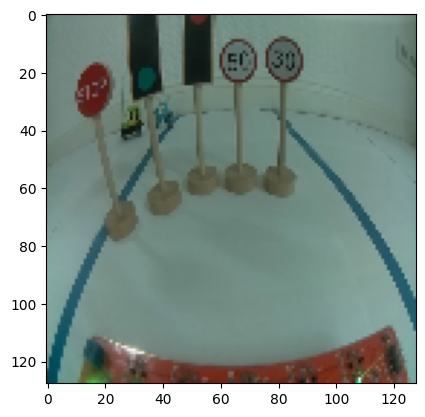

In [7]:
plt.imshow(images[0][:,:,::-1])

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

In [9]:
model = Sequential([
    Input(shape=(images[0].shape)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1)
])

In [10]:
# Modell für Regression kompilieren
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(images, labels, epochs=10, validation_split=0.2, batch_size=32)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 555.1976 - mae: 23.5266 - val_loss: 104.1252 - val_mae: 10.2042
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 58.1984 - mae: 6.7873 - val_loss: 63.2434 - val_mae: 7.9526
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 239.3817 - mae: 14.7415 - val_loss: 13.7552 - val_mae: 3.7088
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 947ms/step - loss: 12.9752 - mae: 2.7295 - val_loss: 2.1029 - val_mae: 1.4502
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 645ms/step - loss: 35.8446 - mae: 4.9507 - val_loss: 4.8846 - val_mae: 2.2101
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 60.4281 - mae: 6.9471 - val_loss: 25.8429 - val_mae: 5.0836
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 651ms/step - loss: 19.9115 - mae: 4.0952 - val_loss: 39.6938 - val_mae: 6.3003
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 669ms/step - loss: 34.8764 - mae: 5.6760 - val_loss: 36.9277 - val_mae: 6.0768
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step - loss: 100.77

In [13]:
def plot_train_history(history):
  plt.plot(history.history['loss'], color='blue')
  plt.plot(history.history['val_loss'], color='red')
  plt.legend(["training loss", "validation loss"])

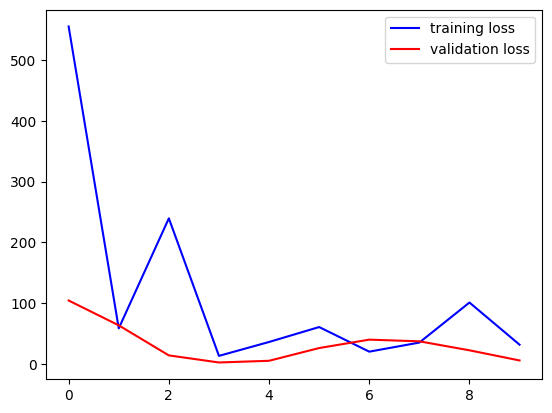

In [14]:
plot_train_history(history)

In [15]:
model.save('my_model.keras') #.keras

In [16]:
loaded_model = tf.keras.models.load_model('my_model.keras')

In [17]:
 loaded_model.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


array([[21.173326],
       [22.562994],
       [20.202152],
       [20.670729]], dtype=float32)

In [18]:
loaded_model.predict(images[0].reshape(-1, *images[0].shape))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


array([[21.173326]], dtype=float32)

In [19]:
img_reshaped = np.array([images[0]])

In [42]:
%%time
loaded_model.predict(img_reshaped)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
CPU times: user 138 ms, sys: 4.81 ms, total: 143 ms
Wall time: 158 ms


array([[21.173326]], dtype=float32)

In [43]:
%%time
loaded_model(img_reshaped)

CPU times: user 39.7 ms, sys: 2.95 ms, total: 42.7 ms
Wall time: 30.1 ms


<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[21.173326]], dtype=float32)>

## TFLite

In [22]:
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)

In [23]:
tflite_model = converter.convert()

Saved artifact at '/tmp/tmpf6c05qgk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135683314715536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135683314714576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135683314715344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135683314715152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135683314712848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135683314716688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135686099051216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135683382317840: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [24]:
 with open("TFLite_Modell.tflite", 'wb') as f:
    f.write(tflite_model)

In [25]:
np.__version__

'1.26.0'

## Auf dem Raspi

In [26]:
# Falls noch nicht installiert
!python3 -m pip install tflite-runtime

In [27]:
import tflite_runtime.interpreter as tflite

In [28]:
interpreter = tflite.Interpreter(model_path="TFLite_Modell.tflite") # path=Pfad zur .tflite Datei
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
interpreter.allocate_tensors()

In [44]:
 %%time
interpreter.set_tensor(input_details[0]['index'], img_reshaped.astype(np.float32))
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
output_data

CPU times: user 15.6 ms, sys: 106 µs, total: 15.7 ms
Wall time: 15.3 ms


array([[21.173326]], dtype=float32)

# Data Augmentation

In [34]:
!pip install imgaug

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 13.8 MB/s eta 0:00:00


In [35]:
from imgaug import augmenters as img_aug
import random

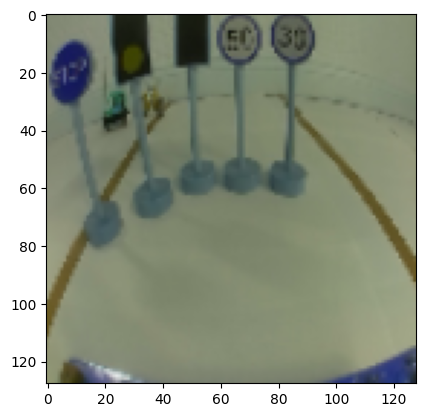

In [36]:
def zoom(image):
    zoom = img_aug.Affine(scale=(1, 1.3))  # zoom from 100% (no zoom) to 130%
    image = zoom.augment_image(image)
    return image

zoomed = zoom(images[0])
plt.imshow(zoomed)

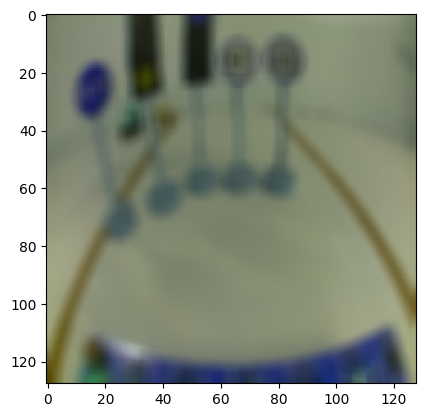

In [38]:
def blur(image):
    # kernel larger than 5 would make the image way too blurry
    kernel_size = random.randint(1, 5)
    image = cv2.blur(image, (kernel_size, kernel_size))

    return image

blurred = blur(images[0])
plt.imshow(blurred)

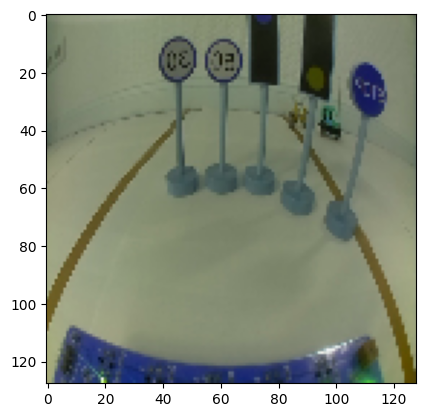

In [39]:
def random_flip(image, steering_angle):
    is_flip = random.randint(0, 1)
    if is_flip == 1:
        # randomly flip horizon
        image = cv2.flip(image, 1)
        steering_angle = 180 - steering_angle

    return image, steering_angle

flipped = random_flip(images[0], labels[0])
plt.imshow(flipped[0])

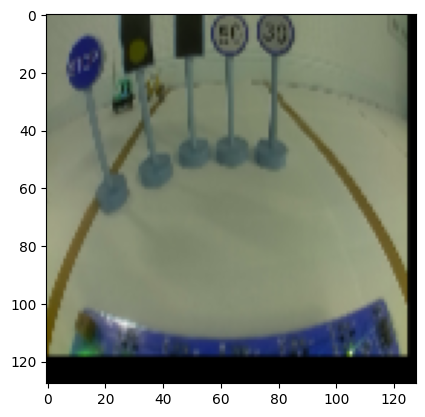

In [40]:
def pan(image):
    # pan left / right / up / down about 10%
    pan = img_aug.Affine(translate_percent={
                         "x": (-0.1, 0.1), "y": (-0.1, 0.1)})
    image = pan.augment_image(image)
    return image

panned = pan(images[0])
plt.imshow(panned)

In [ ]:
def random_augment(image: np.array, steering_angle: float) -> tuple:
    """randomly augment number of images (usually for training)

    Args:
        image (np.array): image to be augmented
        steering_angle (float): the stearing angle associated to image.

    Returns:
        tuple(np.array, float): newly created image and associated steering angle.
    """
    if np.random.rand() < 0.5:
        image = pan(image)
    if np.random.rand() < 0.5:
        image = zoom(image)
    if np.random.rand() < 0.5:
        image = blur(image)
    if np.random.rand() < 0.5:
        image = adjust_brightness(image)
    image, steering_angle = random_flip(image, steering_angle)

    return image, steering_angle